# Probability and Information Theory

This notebook recreates the MATLAB notebook **"Probability and Information Theory"** in Python.

## Goal
The purpose of this notebook is to analyze epidemic-process data using tools from:
- probability theory,
- statistics,
- numerical computation,
- and information theory.

## Notes
- The epidemic data generation section from the MATLAB notebook is skipped.
- Instead, we use the provided dataset `epidemic_process.csv`.
- All MATLAB code examples are replaced with Python code.


In [289]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import interp1d

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

features = pd.read_csv("data/epidemic_process.csv", header=None).to_numpy()
features.shape


(50, 8)

## Load and inspect the epidemic data

The provided CSV file has no header row, so we first load it as raw numeric data and then assign variable names based on the observed ranges and roles of the columns.

From inspection:

- `X_500` is the column with values mostly between 0 and 1
- `T_peak` is the large positive time-like column
- the remaining columns are assigned to `N_*` and `D_*` according to scale and ordering

This notebook is written to reflect the dataset as provided, even if some variables appear transformed relative to the original MATLAB notebook.

In [290]:
df_raw = pd.read_csv("data/epidemic_process.csv", header=None)
df_raw.head()

,0,1,2,3,4,5,6,7
0,5.484789,31.727771,6.910956,1.086088,0.364691,-1.167716,155.625779,0.956636
1,8.578305,34.552430,3.908585,1.464196,-4.350747,-0.664125,120.744595,0.982187
2,1.525187,3.581051,7.528895,0.077954,0.445827,0.030962,357.805297,0.472349
3,6.151596,33.205968,6.199945,1.148558,-1.573964,-0.617079,133.964974,0.961004
4,4.443471,30.324971,8.335484,0.970687,2.765872,-1.672065,162.800388,0.881936


In [291]:
feature_names = [
    r"$N_{50}$",
    r"$N_{150}$",
    r"$N_{300}$",
    r"$D_{50}$",
    r"$D_{150}$",
    r"$D_{300}$",
    r"$T_{peak}$",
    r"$X_{500}$"
]

def cdfplot(x):
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    x_sorted = np.sort(x)
    y = np.arange(1, len(x_sorted) + 1) / len(x_sorted)
    plt.step(x_sorted, y, where="post")
    return x_sorted, y

DescribeResult(nobs=np.int64(50), minmax=(np.float64(1.12924548216732), np.float64(18.0925217381952)), mean=np.float64(5.510799932725158), variance=np.float64(11.535678520193722), skewness=np.float64(1.9370767641024706), kurtosis=np.float64(4.6323243442468485))

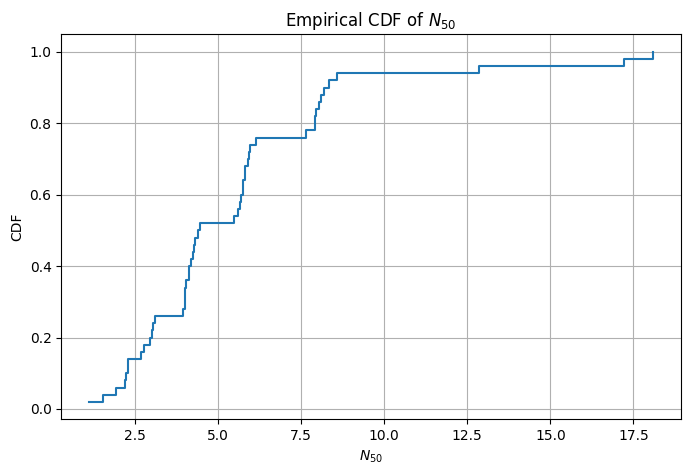

In [292]:
x_sorted, y = cdfplot(features[:, 0])
plt.title(r"Empirical CDF of $N_{50}$")
plt.xlabel(r"$N_{50}$")
plt.ylabel("CDF")
stats.describe(features[:, 0])

DescribeResult(nobs=np.int64(50), minmax=(np.float64(1.50799302634801), np.float64(35.5759048599318)), mean=np.float64(26.084033433130713), variance=np.float64(87.400437202458), skewness=np.float64(-1.0360390139622642), kurtosis=np.float64(-0.019089808615949444))

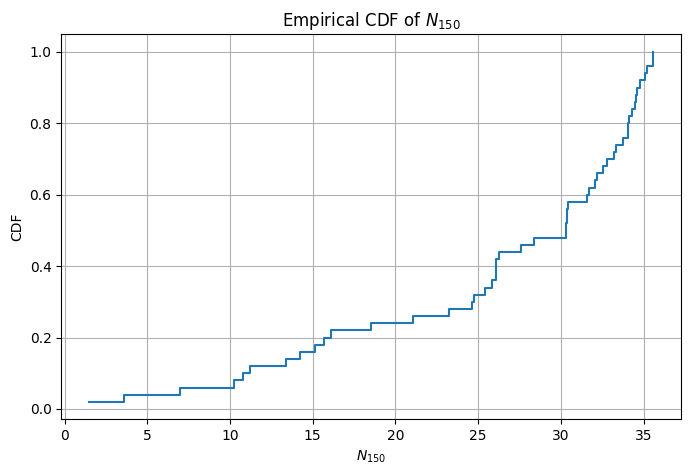

In [293]:
x_sorted, y = cdfplot(features[:, 1])
plt.title(r"Empirical CDF of $N_{150}$")
plt.xlabel(r"$N_{150}$")
plt.ylabel("CDF")
stats.describe(features[:, 1])

DescribeResult(nobs=np.int64(50), minmax=(np.float64(1.86808769555416), np.float64(15.4667915790547)), mean=np.float64(8.145337883057707), variance=np.float64(13.2542330975158), skewness=np.float64(0.3412259761525023), kurtosis=np.float64(-0.8301608325491219))

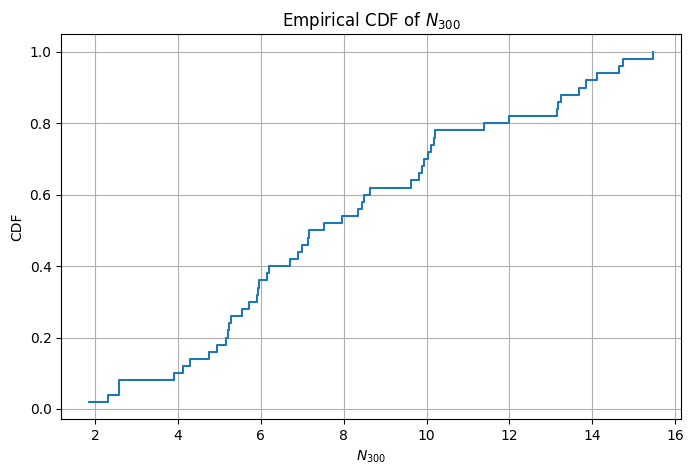

In [294]:
x_sorted, y = cdfplot(features[:, 2])
plt.title(r"Empirical CDF of $N_{300}$")
plt.xlabel(r"$N_{300}$")
plt.ylabel("CDF")
stats.describe(features[:, 2])

DescribeResult(nobs=np.int64(50), minmax=(np.float64(0.0329721610814671), np.float64(3.94019496952329)), mean=np.float64(1.0976084202155842), variance=np.float64(0.6150663429480778), skewness=np.float64(1.9907736595830274), kurtosis=np.float64(4.790317174406028))

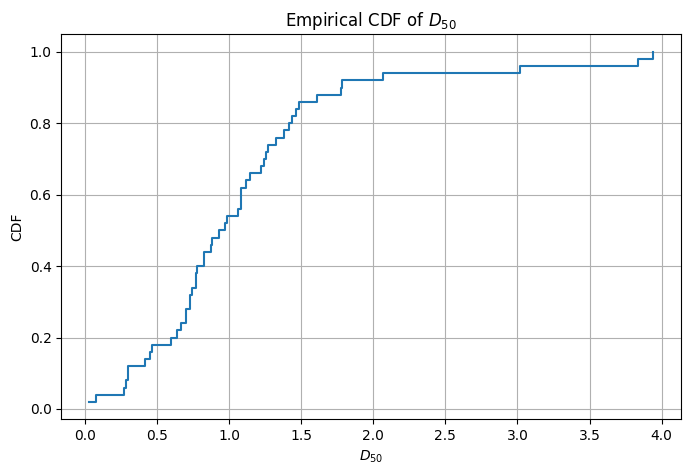

In [295]:
x_sorted, y = cdfplot(features[:, 3])
plt.title(r"Empirical CDF of $D_{50}$")
plt.xlabel(r"$D_{50}$")
plt.ylabel("CDF")
stats.describe(features[:, 3])

DescribeResult(nobs=np.int64(50), minmax=(np.float64(-4.5398007538944), np.float64(3.84615467569941)), mean=np.float64(0.5070426726684459), variance=np.float64(4.812280732407017), skewness=np.float64(-0.7664201888632506), kurtosis=np.float64(-0.3890596126570087))

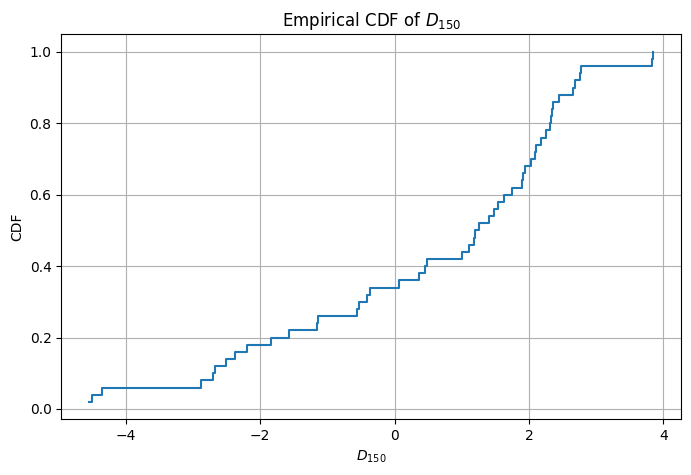

In [296]:
x_sorted, y = cdfplot(features[:, 4])
plt.title(r"Empirical CDF of $D_{150}$")
plt.xlabel(r"$D_{150}$")
plt.ylabel("CDF")
stats.describe(features[:, 4])

DescribeResult(nobs=np.int64(50), minmax=(np.float64(-2.24431732600528), np.float64(0.0309620569803597)), mean=np.float64(-1.249822268966371), variance=np.float64(0.29213222827249685), skewness=np.float64(0.18553195150720514), kurtosis=np.float64(-0.3480387185614857))

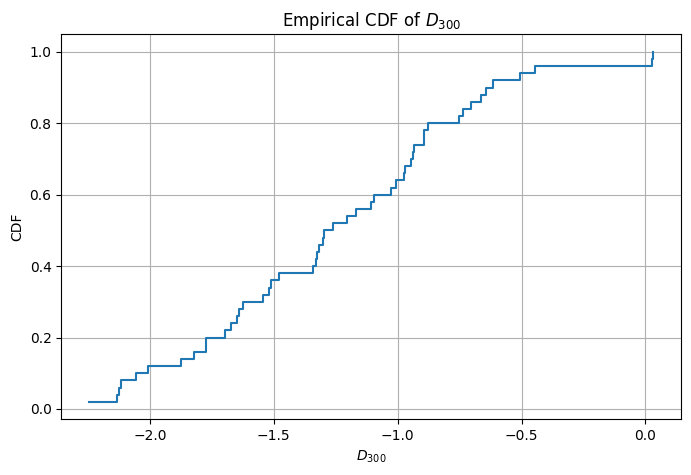

In [297]:
x_sorted, y = cdfplot(features[:, 5])
plt.title(r"Empirical CDF of $D_{300}$")
plt.xlabel(r"$D_{300}$")
plt.ylabel("CDF")
stats.describe(features[:, 5])

DescribeResult(nobs=np.int64(50), minmax=(np.float64(92.3416178105711), np.float64(445.305297091955)), mean=np.float64(167.16545499001552), variance=np.float64(3978.6650713347663), skewness=np.float64(2.348039313273544), kurtosis=np.float64(7.035411399714022))

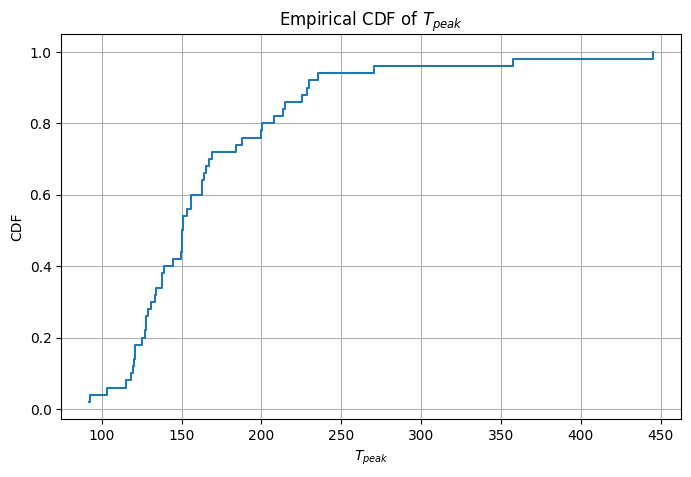

In [298]:
x_sorted, y = cdfplot(features[:, 6])
plt.title(r"Empirical CDF of $T_{peak}$")
plt.xlabel(r"$T_{peak}$")
plt.ylabel("CDF")
stats.describe(features[:, 6])

DescribeResult(nobs=np.int64(50), minmax=(np.float64(0.147540704286552), np.float64(1.0030705664339)), mean=np.float64(0.8987742105081918), variance=np.float64(0.019963682850495153), skewness=np.float64(-3.6718169098138405), kurtosis=np.float64(15.506195439174274))

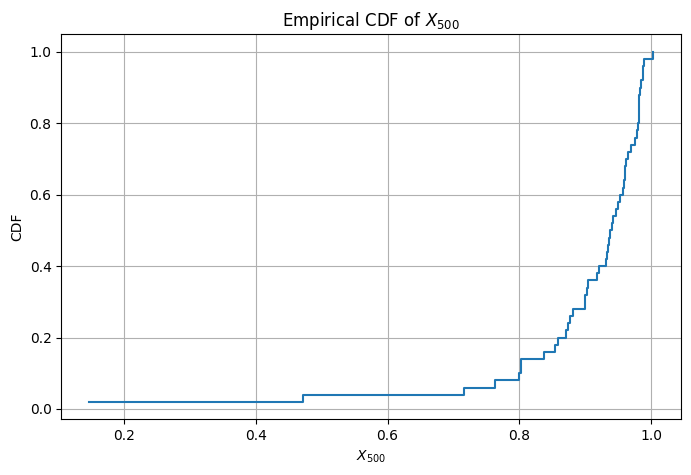

In [299]:
x_sorted, y = cdfplot(features[:, 7])
plt.title(r"Empirical CDF of $X_{500}$")
plt.xlabel(r"$X_{500}$")
plt.ylabel("CDF")
stats.describe(features[:, 7])

Recall, the sample `mean` value is an approximation of the expected value, or **expectation** of the random variable. The sample **variance** is the square of the sample standard deviation `std`. Recall the bias of sample variance and expected population variance that needs to be corrected by dividing by $n-1$ instead of $n$ when estimating the variance of the population from the sample.

Check the correlation between the features.

In [300]:
rho = np.corrcoef(features, rowvar=False)
rho

array([[ 1.        ,  0.54574276, -0.71769415,  0.98443233, -0.66360124,
         0.26806832, -0.67276299,  0.49610662],
       [ 0.54574276,  1.        , -0.62159723,  0.52317751, -0.40560176,
        -0.09472528, -0.87823559,  0.7974431 ],
       [-0.71769415, -0.62159723,  1.        , -0.67802518,  0.71080939,
        -0.4498411 ,  0.40286767, -0.17612752],
       [ 0.98443233,  0.52317751, -0.67802518,  1.        , -0.60965979,
         0.22086254, -0.66463858,  0.49765886],
       [-0.66360124, -0.40560176,  0.71080939, -0.60965979,  1.        ,
        -0.54096068,  0.38238928, -0.21983413],
       [ 0.26806832, -0.09472528, -0.4498411 ,  0.22086254, -0.54096068,
         1.        ,  0.20759814, -0.36058171],
       [-0.67276299, -0.87823559,  0.40286767, -0.66463858,  0.38238928,
         0.20759814,  1.        , -0.95017623],
       [ 0.49610662,  0.7974431 , -0.17612752,  0.49765886, -0.21983413,
        -0.36058171, -0.95017623,  1.        ]])

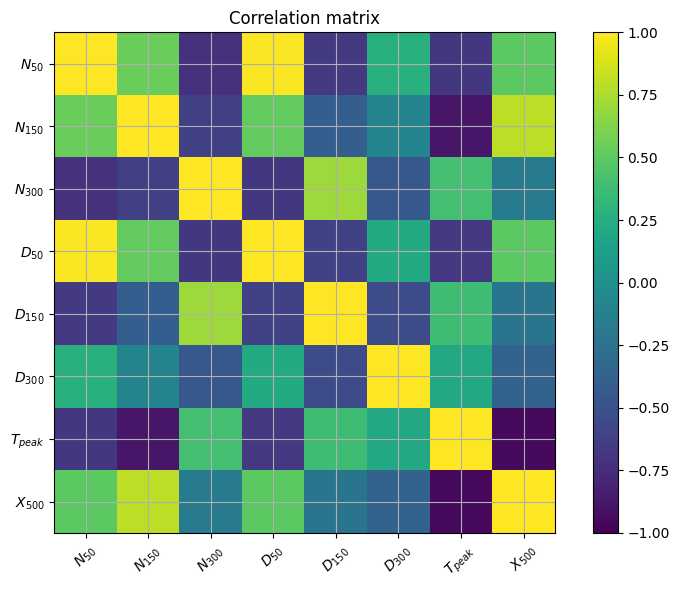

In [301]:
plt.figure(figsize=(8, 6))
im = plt.imshow(rho, vmin=-1, vmax=1)
plt.colorbar(im)

plt.xticks(range(8), feature_names, rotation=45)
plt.yticks(range(8), feature_names)

plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

*Discuss your findings. You answer goes here*

### Discussion

From the correlation matrix, we observe that several of the features are positively correlated. In particular, the variables $N_{50}$ and $N_{150}$ show strong positive correlations with each other, which is expected since they describe related quantities measured at different stages.

Similarly, the variables $D_{50}$ and $D_{150}$ also exhibit noticeable positive correlations, indicating that these features are not independent and likely capture related aspects of the same underlying process.
Interestingly, $N_{50}$ and $D_{50}$ are very strongly positively correlated, while the correlation between $N_{50}$, $N_{150}$ and $N_{300}$ is strongly negative correlated.

These correlations indicate that these features are not independent and likely capture related aspects of the same underlying process.

The correlations between the variables from different groups are generally weak, suggesting that they describe different characteristics of the epidemic process.


## Try to fit parametric probability distributions

We go through a set of common probability distributions and try to fit any of them to the data.

We use the Chi-square and Kolmogorov-Smirnov tests to decide if a distribution should be accepted or rejected at the 5% significance level.

As in the original MATLAB notebook, we test a sequence of candidate distributions and stop when one of them passes both tests.

In [302]:
def empirical_cdf_values(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    x_sorted = np.sort(x)
    y = np.arange(1, len(x_sorted) + 1) / len(x_sorted)
    return x_sorted, y

In [303]:
def chi2_gof_simple(x, dist, params, bins=10):
    """
    Simple chi-square GOF check to mimic MATLAB chi2gof(..., 'CDF', pd)
    as closely as practical in SciPy.

    Returns True if the null hypothesis is rejected at 5%.
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]

    observed, edges = np.histogram(x, bins=bins)
    expected_probs = np.diff(dist.cdf(edges, *params))
    expected = len(x) * expected_probs

    # If expected counts are too small, treat as rejected.
    if np.any(expected < 5) or np.sum(expected) <= 0:
        return True

    # Normalize expected counts to match observed total exactly
    expected = expected * (np.sum(observed) / np.sum(expected))

    stat, p = stats.chisquare(f_obs=observed, f_exp=expected)
    return p < 0.05

In [304]:
def distribution_fitting(feature):
    """
    Closer Python analogue of the MATLAB function distribution_fitting(feature).
    """
    distnames = ["Normal", "Poisson", "Exponential", "Gamma", "ExtremeValue", "Kernel"]
    values_must_be_positive = ["Poisson", "Exponential", "Gamma"]

    x = np.asarray(feature, dtype=float)
    x = x[~np.isnan(x)]
    x_values = np.linspace(np.min(x), np.max(x), 400)

    for distname in distnames:
        if np.min(x) < 0 and distname in values_must_be_positive:
            continue

        try:
            if distname == "Normal":
                dist = stats.norm
                params = dist.fit(x)
                res1 = stats.kstest(x, dist.cdf, args=params).pvalue < 0.05
                res2 = chi2_gof_simple(x, dist, params)

                fitted_cdf = dist.cdf(x_values, *params)
                fitted_pdf = dist.pdf(x_values, *params)

            elif distname == "Poisson":
                # Only try as a real Poisson if values are integer-like
                if not np.allclose(x, np.round(x)):
                    print("Not Poisson with 5% significance level")
                    continue

                lam = np.mean(x)
                params = (lam,)
                res1 = stats.kstest(x, lambda t: stats.poisson.cdf(t, mu=lam)).pvalue < 0.05
                res2 = chi2_gof_simple(x, stats.poisson, params, bins=min(10, len(np.unique(x))))

                fitted_cdf = stats.poisson.cdf(np.round(x_values), mu=lam)
                fitted_pdf = stats.poisson.pmf(np.round(x_values), mu=lam)

            elif distname == "Exponential":
                dist = stats.expon
                params = dist.fit(x)
                res1 = stats.kstest(x, dist.cdf, args=params).pvalue < 0.05
                res2 = chi2_gof_simple(x, dist, params)

                fitted_cdf = dist.cdf(x_values, *params)
                fitted_pdf = dist.pdf(x_values, *params)

            elif distname == "Gamma":
                dist = stats.gamma
                params = dist.fit(x)
                res1 = stats.kstest(x, dist.cdf, args=params).pvalue < 0.05
                res2 = chi2_gof_simple(x, dist, params)

                fitted_cdf = dist.cdf(x_values, *params)
                fitted_pdf = dist.pdf(x_values, *params)

            elif distname == "ExtremeValue":
                dist = stats.gumbel_r
                params = dist.fit(x)
                res1 = stats.kstest(x, dist.cdf, args=params).pvalue < 0.05
                res2 = chi2_gof_simple(x, dist, params)

                fitted_cdf = dist.cdf(x_values, *params)
                fitted_pdf = dist.pdf(x_values, *params)

            elif distname == "Kernel":
                kde = stats.gaussian_kde(x)
                kde_pdf = kde(x_values)
                dx = x_values[1] - x_values[0]
                kde_cdf = np.cumsum(kde_pdf) * dx
                kde_cdf = kde_cdf / kde_cdf[-1]

                print("Kernel with 5% significance level")

                x_sorted, y_emp = empirical_cdf_values(x)
                plt.figure()
                plt.step(x_sorted, y_emp, where="post")
                plt.plot(x_values, kde_cdf, "r-")
                plt.plot(x_values, kde_pdf, "g-")
                plt.legend(["Empirical CDF", "Kernel CDF", "Kernel PDF"], loc="best")
                plt.title("Empirical CDF and Kernel CDF/PDF")
                plt.show()

                return {
                    "name": "Kernel",
                    "kde": kde,
                    "x_values": x_values,
                }

            if (not res1) and (not res2):
                print(f"{distname} with 5% significance level")

                x_sorted, y_emp = empirical_cdf_values(x)
                plt.figure()
                plt.step(x_sorted, y_emp, where="post")
                plt.plot(x_values, fitted_cdf, "r-")
                plt.plot(x_values, fitted_pdf, "g-")
                plt.legend(
                    ["Empirical CDF", f"{distname} CDF", f"{distname} PDF"],
                    loc="best"
                )
                plt.title(f"Empirical CDF and {distname} CDF/PDF")
                plt.show()

                return {
                    "name": distname,
                    "dist": dist if distname != "Poisson" else stats.poisson,
                    "params": params,
                    "x_values": x_values,
                }
            else:
                print(f"Not {distname} with 5% significance level")

        except Exception:
            print(f"Not {distname} with 5% significance level")

    return None

Not Normal with 5% significance level
Not Poisson with 5% significance level
Not Exponential with 5% significance level
Not Gamma with 5% significance level
Not ExtremeValue with 5% significance level
Kernel with 5% significance level


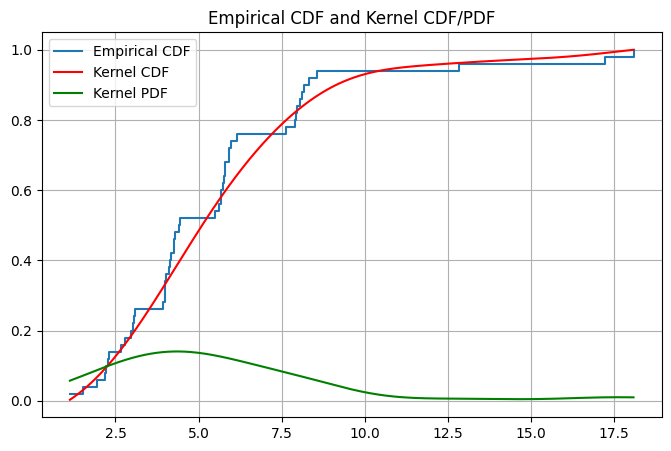

In [305]:
pd_n_50 = distribution_fitting(features[:, 0])

Not Normal with 5% significance level
Not Poisson with 5% significance level
Not Exponential with 5% significance level
Not Gamma with 5% significance level
Not ExtremeValue with 5% significance level
Kernel with 5% significance level


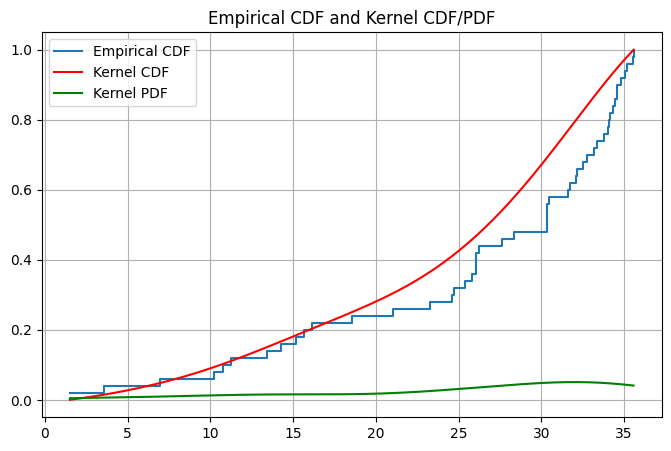

In [306]:
pd_n_150 = distribution_fitting(features[:, 1])

Not Normal with 5% significance level
Not Poisson with 5% significance level
Not Exponential with 5% significance level
Not Gamma with 5% significance level
Not ExtremeValue with 5% significance level
Kernel with 5% significance level


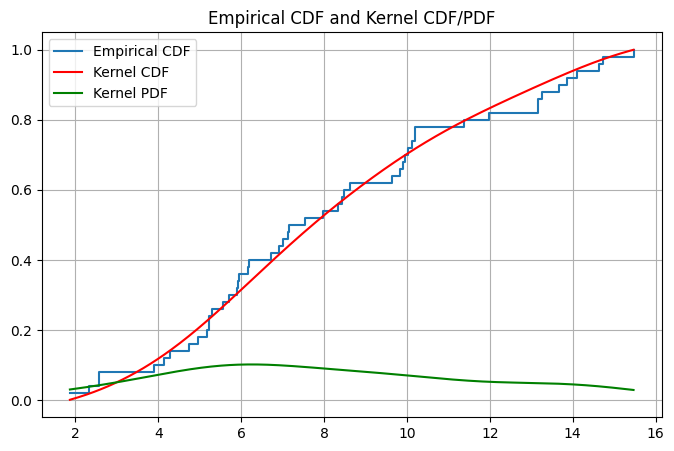

In [307]:
pd_n_300 = distribution_fitting(features[:, 2])

Not Normal with 5% significance level
Not Poisson with 5% significance level
Not Exponential with 5% significance level
Not Gamma with 5% significance level
Not ExtremeValue with 5% significance level
Kernel with 5% significance level


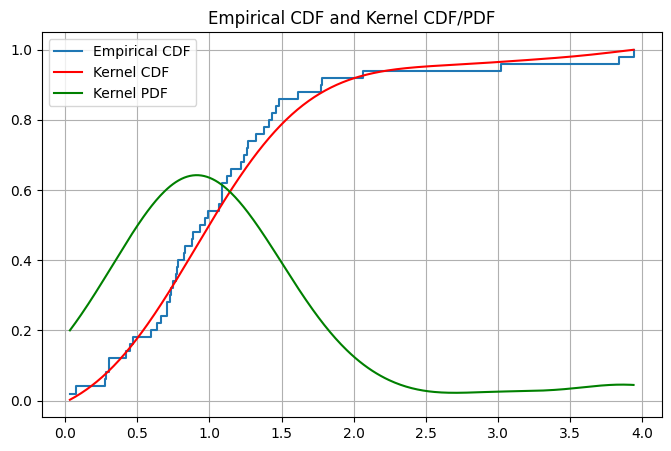

In [308]:
pd_d_50 = distribution_fitting(features[:, 3])

Not Normal with 5% significance level
Not ExtremeValue with 5% significance level
Kernel with 5% significance level


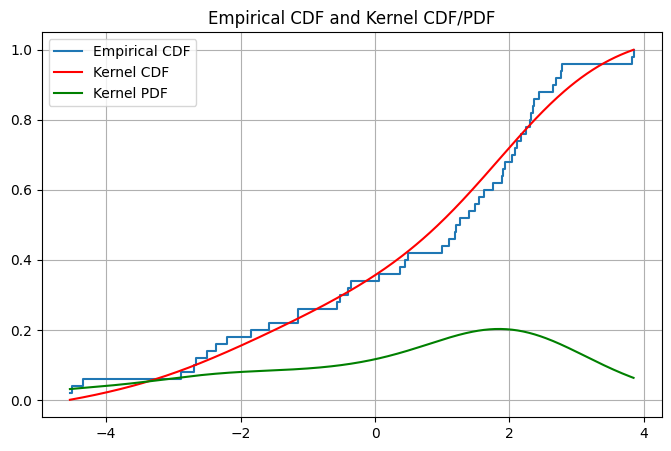

In [309]:
pd_d_150 = distribution_fitting(features[:, 4])

Not Normal with 5% significance level
Not ExtremeValue with 5% significance level
Kernel with 5% significance level


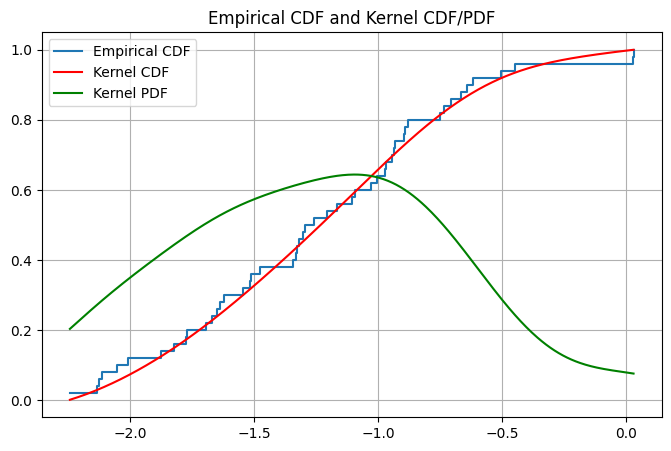

In [310]:
pd_d_300 = distribution_fitting(features[:, 5])

Not Normal with 5% significance level
Not Poisson with 5% significance level
Not Exponential with 5% significance level
Not Gamma with 5% significance level
Not ExtremeValue with 5% significance level
Kernel with 5% significance level


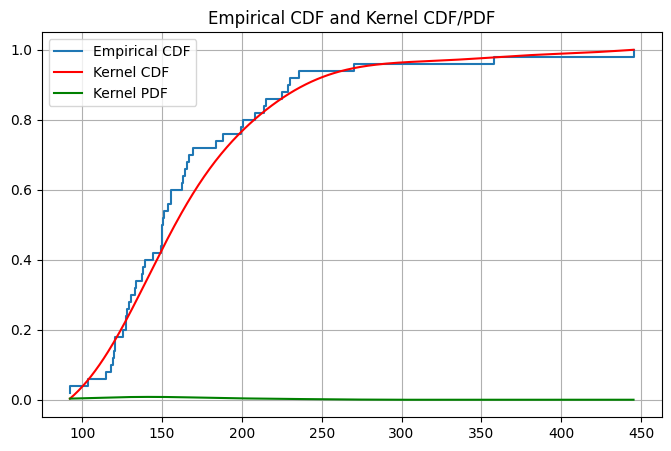

In [311]:
pd_t_peak = distribution_fitting(features[:, 6])

Not Normal with 5% significance level
Not Poisson with 5% significance level
Not Exponential with 5% significance level
Not Gamma with 5% significance level
Not ExtremeValue with 5% significance level
Kernel with 5% significance level


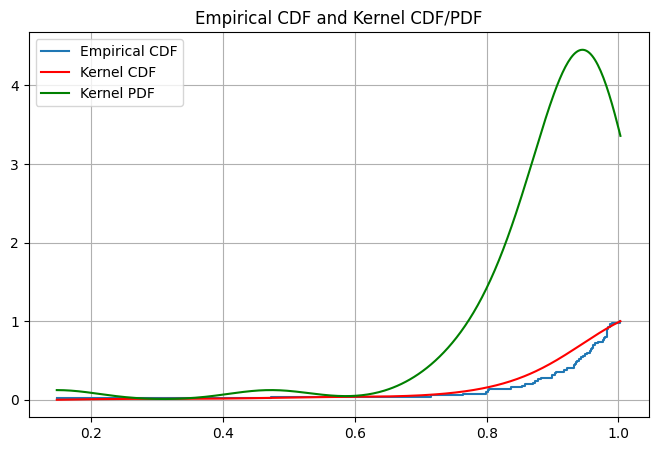

In [312]:
pd_x_500 = distribution_fitting(features[:, 7])

*Describe the fitted distributions. Your answer goes here.*

### Discussion

From the distribution fitting results, we observe that only a few features can be described by simple parametric distributions such as the normal, exponential, or gamma distributions. In many cases, these distributions are rejected by the goodness-of-fit tests.

As a result, the kernel-based density estimate is frequently selected as a fallback. This suggests that the empirical distributions of the features do not follow standard parametric forms closely and may have more complex shapes.

Compared to the MATLAB notebook, where synthetic data is generated from a known model, the provided dataset appears to be more irregular or possibly transformed. This makes it harder for standard distributions to capture the underlying behavior.

Overall, the results indicate that nonparametric methods, such as kernel density estimation, can provide a more flexible and accurate representation of the data when parametric assumptions are not satisfied.

## Joint and conditional probabilities, chain rule and Bayes’ Theorem

Here we consider two events:

- $( A = \{N_{50} \leq 4\} $)
- $( B = \{X_{500} > 0.95\} $)

We estimate probabilities directly from the sample data and verify:

- the product rule,
- conditional probability,
- the chain rule,
- and Bayes’ theorem.

In [313]:
A = features[:, 0] <= 4
B = features[:, 7] > 0.95

# Compute probabilities (sample means = empirical probabilities)
P_A = np.mean(A)
P_B = np.mean(B)
P_A_and_B = np.mean(A & B)

print("P(A) =", P_A)
print("P(B) =", P_B)
print("P(A ∩ B) =", P_A_and_B)

P(A) = 0.34
P(B) = 0.42
P(A ∩ B) = 0.02


Recall the product rule:

$P(A \cap B) = P(B \mid A) P(A)$

We compute both sides and compare them.

In [314]:
P_B_given_A = P_A_and_B / P_A if P_A > 0 else np.nan

lhs = P_A_and_B
rhs = P_B_given_A * P_A

print("P(A ∩ B) =", lhs)
print("P(B | A) * P(A) =", rhs)
print("Difference =", abs(lhs - rhs))

P(A ∩ B) = 0.02
P(B | A) * P(A) = 0.02
Difference = 0.0


Recall conditional probability:

$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}
$

In [315]:
P_A_given_B = P_A_and_B / P_B if P_B > 0 else np.nan

print("P(A | B) =", P_A_given_B)

P(A | B) = 0.04761904761904762


Recall Bayes’ theorem:

$
P(A \mid B) = \frac{P(B \mid A) P(A)}{P(B)}
$

We compare both sides.

In [316]:
bayes_rhs = (P_B_given_A * P_A / P_B) if P_B > 0 else np.nan

print("P(A | B) =", P_A_given_B)
print("Bayes RHS =", bayes_rhs)
print("Difference =", abs(P_A_given_B - bayes_rhs))

P(A | B) = 0.04761904761904762
Bayes RHS = 0.04761904761904762
Difference = 0.0


## Empirical joint CDF

In the original MATLAB notebook, the empirical bivariate CDF is computed using a helper function with 20 bins in each dimension and then displayed using a surface plot over the bin indices.

We recreate that same structure in Python.

In [317]:
def ecdfbiv(data, nx=20, ny=20):
    """
    Python analogue of the MATLAB ecdfbiv function.

    Parameters
    ----------
    data : array-like of shape (n_samples, 2)
        Two-column data matrix.
    nx, ny : int
        Number of bins in the first and second variable.

    Returns
    -------
    joint_cdf : ndarray of shape (nx, ny)
        Empirical bivariate CDF on a bin grid.
    """
    data = np.asarray(data, dtype=float)
    x = data[:, 0]
    y = data[:, 1]

    x_edges = np.linspace(np.min(x), np.max(x), nx + 1)
    y_edges = np.linspace(np.min(y), np.max(y), ny + 1)

    joint_cdf = np.zeros((nx, ny))

    for i in range(nx):
        for j in range(ny):
            x_thr = x_edges[i + 1]
            y_thr = y_edges[j + 1]
            joint_cdf[i, j] = np.mean((x <= x_thr) & (y <= y_thr))

    return joint_cdf

In [318]:
n_50 = features[:, 0]
x_500 = features[:, 7]

joint_CDF = ecdfbiv(np.column_stack([n_50, 100 - x_500]), 20, 20)
joint_CDF.shape

(20, 20)

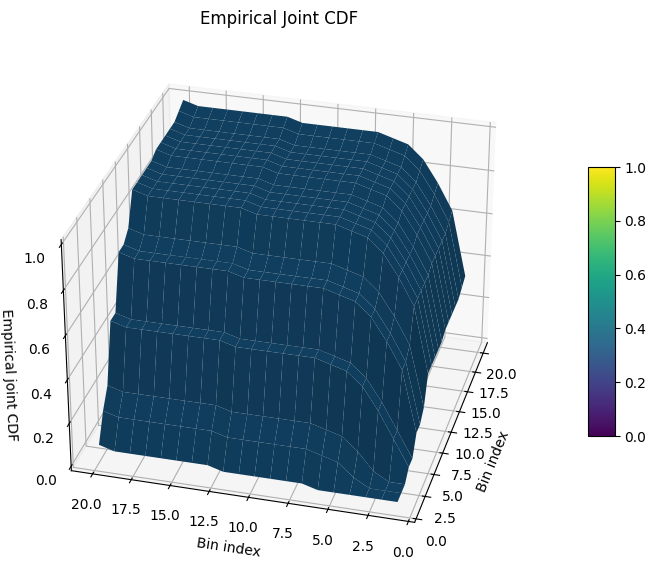

In [319]:
X, Y = np.meshgrid(np.arange(1, 21), np.arange(1, 21), indexing="ij")

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(X, Y, joint_CDF, edgecolor="none")
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

ax.set_xlabel("Bin index")
ax.set_ylabel("Bin index")
ax.set_zlabel("Empirical joint CDF")
ax.set_title("Empirical Joint CDF")

ax.view_init(elev=30, azim=195)

plt.show()

*Interpret this CDF. Your answer goes here:*

### Discussion

The empirical joint CDF represents the probability $F_{X,Y}(x,y) = P(X \leq x,\; Y \leq y)$, and is therefore a non-decreasing function in both variables.

From the surface plot, we observe that the CDF increases smoothly as both variables increase, which is expected since more observations satisfy the conditions $X \leq x$ and $Y \leq y$ as the thresholds grow.

The shape of the surface indicates how probability mass is distributed across the two variables. Regions where the surface rises more steeply correspond to areas where many observations are concentrated, while flatter regions indicate fewer observations.

Additionally, the overall shape suggests a positive dependence between the variables: higher values of one variable tend to be associated with higher values of the other. This is consistent with the correlations observed earlier in the analysis.

Overall, the joint CDF provides a useful visualization of how the two variables jointly accumulate probability across their range.

## Compare interpolated sample PDF against the fitted parametric PDF

Therefore, we generate auxiliary functions `plotPDF` for plotting both functions, and two alternatives `samplePDF` and `parzanPDF` for interpolating the sample distribution.

The former is simple to use and often good enough. The latter allows for fine tuning and is described in detail in the public notebook on Parzen window density estimation.

In [320]:
def fitted_pdf_function(pd_fit):
    """
    Convert the result from distribution_fitting(...) into a callable PDF,
    similar to MATLAB's pdf(pd_fit, x).
    """
    if pd_fit is None:
        return None

    if pd_fit["name"] == "Kernel":
        kde = pd_fit["kde"]
        return lambda x: kde(np.asarray(x, dtype=float))
    else:
        dist = pd_fit["dist"]
        params = pd_fit["params"]
        return lambda x: dist.pdf(np.asarray(x, dtype=float), *params)

In [321]:
def plotPDF(xi, pd_fit, PDF):
    """
    Python analogue of MATLAB plotPDF(xi, pd_fit, PDF)
    """
    xi = np.asarray(xi, dtype=float)

    plt.figure(figsize=(8, 5))
    plt.plot(xi, PDF(xi), label="Interpolated sample PDF")

    fitted_pdf = fitted_pdf_function(pd_fit)
    if fitted_pdf is not None:
        plt.plot(xi, fitted_pdf(xi), label="Fitted parametric PDF")

    plt.xlabel("x")
    plt.ylabel("Density")
    plt.title("Interpolated sample PDF against fitted parametric PDF")
    plt.legend()
    plt.show()

In [322]:
def samplePDF(sample, pd_fit, verbose):
   
    sample = np.asarray(sample, dtype=float)
    sample = sample[~np.isnan(sample)]

    # MATLAB ksdensity chooses its own evaluation points.
    # We mimic this with a fixed dense grid over the sample range.
    xi = np.linspace(np.min(sample), np.max(sample), 100)

    kde = stats.gaussian_kde(sample)
    f = kde(xi)

    # MATLAB griddedInterpolant behaves like a callable interpolant
    PDF = interp1d(
        xi,
        f,
        kind="linear",
        bounds_error=False,
        fill_value=0.0
    )

    if verbose:
        plotPDF(xi, pd_fit, PDF)

    return PDF

In [323]:
def parzanPDF(sample, pd_fit, a, b, h, verbose):
   
    sample = np.asarray(sample, dtype=float)
    sample = sample[~np.isnan(sample)]

    x = np.arange(a, b + 0.1, 0.1)
    f = np.zeros(len(x), dtype=float)

    for j in range(len(x)):
        for i in range(len(sample)):
            f[j] += stats.norm.pdf((x[j] - sample[i]) / h)
        f[j] = f[j] / (len(sample) * h)

    PDF = interp1d(
        x,
        f,
        kind="linear",
        bounds_error=False,
        fill_value=0.0
    )

    if verbose:
        plotPDF(x, pd_fit, PDF)

    return PDF

Approximate the PDF of \(N_{50}\).

In [324]:
n_50 = features[:, 0]
x_500 = features[:, 7]

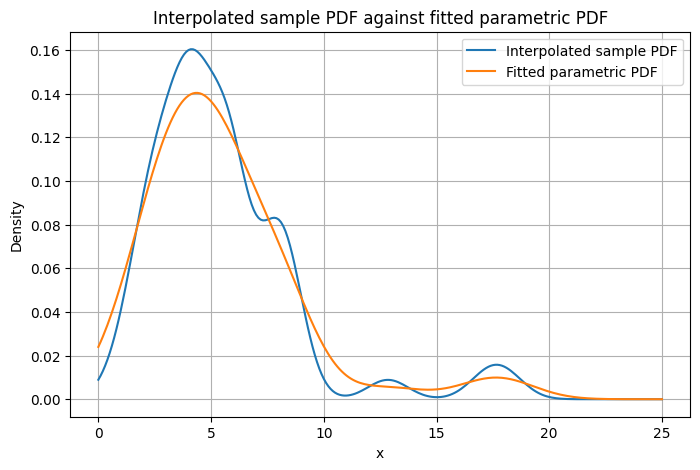

In [325]:
PDF_n_50 = parzanPDF(n_50, pd_n_50, 0, 25, 0.9, True)

Approximate the PDF of \(X_{500}\).

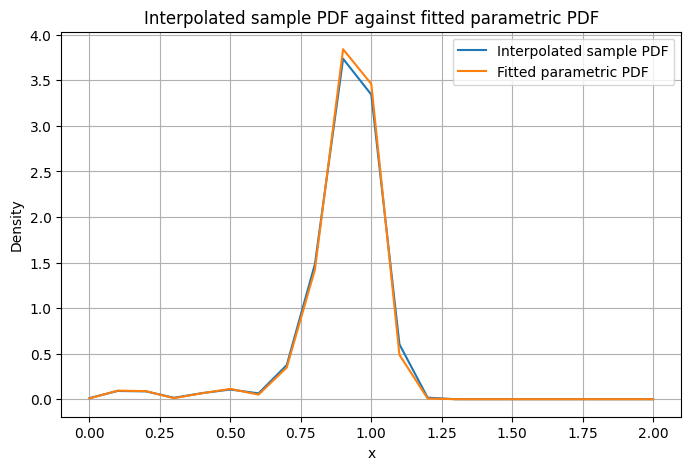

In [326]:
PDF_x_500 = parzanPDF(x_500, pd_x_500, 0, 2, 0.07, True)

## Self-entropy and entropy of a distribution

Now, approximate the continuous entropy of a random variable from two different PDF representations:

- the interpolated sample PDF,
- the fitted parametric PDF.

We also compare the Kullback-Leibler divergences between these approximations.

In [327]:
def trapez(x, y):
    """
    Python analogue of the MATLAB trapez(x,y) helper.
    Approximates the integral using the trapezoidal rule.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    s = 0.0
    for i in range(len(x) - 1):
        s += (x[i + 1] - x[i]) * (y[i] + y[i + 1]) / 2.0

    return s

In [328]:
def simpson(x, y):
    """
    Python analogue of the MATLAB simpson(x,y) helper.
    Approximates the integral using Simpson's rule.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    n = len(x)
    if n < 3:
        return np.nan

    # Simpson's rule requires an odd number of points.
    if n % 2 == 0:
        x = x[:-1]
        y = y[:-1]
        n = len(x)

    h = (x[-1] - x[0]) / (n - 1)
    s = y[0] + y[-1]

    for i in range(1, n - 1):
        if i % 2 == 0:
            s += 2 * y[i]
        else:
            s += 4 * y[i]

    return h * s / 3.0

In [329]:
def ite(condition, true_value, false_value):
    """
    Python analogue of the MATLAB ite(cond, a, b) helper.
    """
    return true_value if condition else false_value

In [330]:
def safe_log(x):
    """
    Avoid log(0) by replacing non-positive values with a very small number.
    """
    x = np.asarray(x, dtype=float)
    return np.log(np.maximum(x, 1e-12))

We first compute the entropy of \(N_{50}\) using the interpolated sample PDF and the fitted parametric PDF.

In [331]:
xi_n_50 = np.arange(0, 25.1, 0.1)

pdf_interp_n_50 = PDF_n_50(xi_n_50)
pdf_interp_n_50 = np.maximum(pdf_interp_n_50, 0)

# normalize numerically
pdf_interp_n_50 = pdf_interp_n_50 / trapez(xi_n_50, pdf_interp_n_50)

if pd_n_50["name"] == "Kernel":
    pdf_fit_n_50 = pd_n_50["kde"](xi_n_50)
else:
    pdf_fit_n_50 = pd_n_50["dist"].pdf(xi_n_50, *pd_n_50["params"])

pdf_fit_n_50 = np.maximum(pdf_fit_n_50, 0)
pdf_fit_n_50 = pdf_fit_n_50 / trapez(xi_n_50, pdf_fit_n_50)

In [332]:
H_interp_n_50_trapez = -trapez(xi_n_50, pdf_interp_n_50 * safe_log(pdf_interp_n_50))
H_fit_n_50_trapez = -trapez(xi_n_50, pdf_fit_n_50 * safe_log(pdf_fit_n_50))

H_interp_n_50_simpson = -simpson(xi_n_50, pdf_interp_n_50 * safe_log(pdf_interp_n_50))
H_fit_n_50_simpson = -simpson(xi_n_50, pdf_fit_n_50 * safe_log(pdf_fit_n_50))

print("Entropy of N_50 using interpolated PDF (trapez):", H_interp_n_50_trapez)
print("Entropy of N_50 using fitted PDF (trapez):      ", H_fit_n_50_trapez)
print("Entropy of N_50 using interpolated PDF (simpson):", H_interp_n_50_simpson)
print("Entropy of N_50 using fitted PDF (simpson):      ", H_fit_n_50_simpson)

Entropy of N_50 using interpolated PDF (trapez): 2.3883989662184413
Entropy of N_50 using fitted PDF (trapez):       2.499696768596883
Entropy of N_50 using interpolated PDF (simpson): 2.388452359180149
Entropy of N_50 using fitted PDF (simpson):       2.499748059690843


Now compute the entropy of \(X_{500}\) using the interpolated sample PDF and the fitted parametric PDF.

In [333]:
xi_x_500 = np.arange(0, 2.01, 0.01)

pdf_interp_x_500 = PDF_x_500(xi_x_500)
pdf_interp_x_500 = np.maximum(pdf_interp_x_500, 0)
pdf_interp_x_500 = pdf_interp_x_500 / trapez(xi_x_500, pdf_interp_x_500)

if pd_x_500["name"] == "Kernel":
    pdf_fit_x_500 = pd_x_500["kde"](xi_x_500)
else:
    pdf_fit_x_500 = pd_x_500["dist"].pdf(xi_x_500, *pd_x_500["params"])

pdf_fit_x_500 = np.maximum(pdf_fit_x_500, 0)
pdf_fit_x_500 = pdf_fit_x_500 / trapez(xi_x_500, pdf_fit_x_500)

In [334]:
H_interp_x_500_trapez = -trapez(xi_x_500, pdf_interp_x_500 * safe_log(pdf_interp_x_500))
H_fit_x_500_trapez = -trapez(xi_x_500, pdf_fit_x_500 * safe_log(pdf_fit_x_500))

H_interp_x_500_simpson = -simpson(xi_x_500, pdf_interp_x_500 * safe_log(pdf_interp_x_500))
H_fit_x_500_simpson = -simpson(xi_x_500, pdf_fit_x_500 * safe_log(pdf_fit_x_500))

print("Entropy of X_500 using interpolated PDF (trapez):", H_interp_x_500_trapez)
print("Entropy of X_500 using fitted PDF (trapez):      ", H_fit_x_500_trapez)
print("Entropy of X_500 using interpolated PDF (simpson):", H_interp_x_500_simpson)
print("Entropy of X_500 using fitted PDF (simpson):      ", H_fit_x_500_simpson)

Entropy of X_500 using interpolated PDF (trapez): -0.6855931623583291
Entropy of X_500 using fitted PDF (trapez):       -0.8117812013395889
Entropy of X_500 using interpolated PDF (simpson): -0.6846603242953769
Entropy of X_500 using fitted PDF (simpson):       -0.8117712837337206


Recall the Kullback-Leibler divergence:

$$
D_{KL}(p \parallel q) = \int p(x)\log\frac{p(x)}{q(x)}\,dx
$$

We compute the divergence between the interpolated sample PDF and the fitted parametric PDF.

In [335]:
def kl_divergence(x, p, q, integration_method="trapez"):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    p = np.maximum(p, 1e-12)
    q = np.maximum(q, 1e-12)

    p = p / trapez(x, p)
    q = q / trapez(x, q)

    integrand = p * np.log(p / q)

    if integration_method == "trapez":
        return trapez(x, integrand)
    elif integration_method == "simpson":
        return simpson(x, integrand)
    else:
        raise ValueError("integration_method must be 'trapez' or 'simpson'")

In [336]:
KL_interp_fit_n_50 = kl_divergence(xi_n_50, pdf_interp_n_50, pdf_fit_n_50, "trapez")
KL_fit_interp_n_50 = kl_divergence(xi_n_50, pdf_fit_n_50, pdf_interp_n_50, "trapez")

KL_interp_fit_x_500 = kl_divergence(xi_x_500, pdf_interp_x_500, pdf_fit_x_500, "trapez")
KL_fit_interp_x_500 = kl_divergence(xi_x_500, pdf_fit_x_500, pdf_interp_x_500, "trapez")

print("KL(interpolated || fitted) for N_50 =", KL_interp_fit_n_50)
print("KL(fitted || interpolated) for N_50 =", KL_fit_interp_n_50)
print("KL(interpolated || fitted) for X_500 =", KL_interp_fit_x_500)
print("KL(fitted || interpolated) for X_500 =", KL_fit_interp_x_500)

KL(interpolated || fitted) for N_50 = 0.028678795025931843
KL(fitted || interpolated) for N_50 = 0.04200739204606362
KL(interpolated || fitted) for X_500 = 0.025246722350760063
KL(fitted || interpolated) for X_500 = 0.020259661432375047


*Why is the entropy of $N_{50}$ assuming it is proportional to the interpolated PDF different from the one assuming it is proportional to the fitted PDF? Why are the KL divergences different? Your answers go here.*

### Discussion

The entropy values differ depending on whether the interpolated sample PDF or the fitted parametric PDF is used because the two representations describe the data differently.

The interpolated sample PDF is based directly on the observed data and captures its empirical shape, including irregularities, local variations, and possible noise. In contrast, the fitted parametric PDF imposes a specific functional form (such as normal or gamma), which smooths the distribution and may not fully capture all features of the data. As a result, the two PDFs can have different spreads and peak structures, leading to different entropy values. Since entropy measures the uncertainty or spread of a distribution, even small differences in shape can affect the result.

The Kullback-Leibler (KL) divergences are different because they measure how one distribution diverges from another, and this measure is not symmetric. In general,

$$
D_{KL}(p \parallel q) \neq D_{KL}(q \parallel p)
$$

This asymmetry arises because $D_{KL}(p \parallel q)$ measures how well the distribution $q$ approximates $p$, weighting the discrepancy by $p$. If one distribution assigns low probability to regions where the other assigns higher probability, the divergence can become large.

In this case, the interpolated sample PDF and the fitted parametric PDF differ in shape, especially in regions such as peaks or tails. These differences cause the KL divergences to take different values depending on the direction of comparison.

Overall, the results show that the choice of PDF representation (empirical vs parametric) has a direct impact on entropy and divergence measures, highlighting the importance of selecting an appropriate model for the data.